**Asignatura:** Inteligencia en Negocios Globales — Universidad EAN  
**Proyecto final — Grupo 3**  
**Producto:** Café verde sin tostar ni descafeinar, **HS 090111**  
**Ficha técnica de referencia:** *Equipo 3 — Ficha técnica* (septiembre de 2026). Las descargas de Trade Map que sustentan las cifras de la ficha se hicieron para este cuaderno y están en `datos/`.

***

## La pregunta del equipo

> ¿Cuál es el potencial de Alemania, Japón y Corea del Sur como mercados alternativos a Estados Unidos para el café verde colombiano, y qué estrategia de diversificación reduce la dependencia de un solo destino?

## Lo que calcula este cuaderno

Cada sección corresponde a un análisis que el equipo propuso en su ficha técnica. El cuaderno **calcula y grafica; no interpreta**. La interpretación es el trabajo del equipo.

| Métrica o análisis | Pregunta que responde |
|---|---|
| **Participación por destino y evolución 2016-2025** | ¿Cuánto pesa Estados Unidos y cuánto pesan Alemania, Japón y Corea del Sur? |
| **CR4 y HHI de destinos** | ¿Qué tan concentrado está el café verde colombiano en pocos mercados? |
| **Tamaño y crecimiento de los mercados importadores** | ¿Cuánto café verde importa cada candidato y a qué ritmo crece? |
| **Proveedores de cada mercado candidato** | ¿Contra quién compite Colombia en Alemania, Japón y Corea (Brasil, Vietnam)? |
| **Matriz comparativa de los tres destinos** | ¿Cómo se comparan en participación, crecimiento, tamaño, acceso y competencia? |
| **Escenarios de diversificación** | ¿Cuánto bajaría la dependencia de Estados Unidos si los tres mercados crecen como en la ficha? |

## Cómo usar este cuaderno

1. Ejecuta las celdas **en orden**, de arriba hacia abajo (`Entorno de ejecución → Ejecutar todas`). Viene en modo `"github"`: descarga sus propios datos del repositorio del curso, no tienes que subir nada.  
2. Después de cada gráfica hay una celda que dice **Análisis del equipo**. Haz doble clic sobre ella y escribe la interpretación. Puedes agregar más celdas de texto donde quieras.  
3. Las celdas marcadas **editable** contienen pesos o puntajes que el equipo debe ajustar con su propio criterio. Cámbialos y vuelve a ejecutar.  
4. Al terminar: `Archivo → Descargar → Descargar .ipynb` y sube el archivo al aula virtual.

Todas las tablas y figuras se guardan además en la carpeta `salidas/` (panel izquierdo de Colab) para que las uses en el informe.

***
# 0. Preparación del entorno

In [ ]:
import os
import io
import csv
import glob
import time
import shutil
import zipfile
import urllib.request
import urllib.error
import urllib.parse

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 170)

# Paleta de colores del curso (validada para lectura accesible en pantalla e impresion)
AZUL      = "#2a78d6"    # serie principal / pais del caso
ROJO      = "#e34948"    # valores negativos (par divergente con el azul)
NARANJA   = "#eb6834"    # elemento destacado
VERDE     = "#3f8f6b"    # segunda serie categorica
GRIS_MID  = "#c3c2b7"    # resto / punto neutro
TINTA     = "#0b0b0b"
GRIS_TEXT = "#52514e"
GRIS_EJE  = "#898781"
REJILLA   = "#e1e0d9"

# Orden fijo de colores para series categoricas: nunca se reciclan, lo que sobra va a "Otros" en gris
CATEGORIAS = [AZUL, NARANJA, VERDE, ROJO]

CARPETA_SALIDA = "salidas"
os.makedirs(CARPETA_SALIDA, exist_ok=True)


def estilo(ax, titulo, subtitulo="", fuente="", eje_y="", eje_x="", rejilla="y"):
    """Aplica el estilo de graficas del curso: titulo a la izquierda, sin marco, rejilla suave, fuente al pie."""
    ax.set_title(titulo + ("\n" + subtitulo if subtitulo else ""),
                 fontsize=13, color=TINTA, loc="left", pad=14)
    ax.set_ylabel(eje_y, fontsize=10, color=GRIS_TEXT)
    ax.set_xlabel(eje_x, fontsize=10, color=GRIS_TEXT)
    if rejilla == "y":
        ax.yaxis.grid(True, color=REJILLA, linewidth=0.8)
    elif rejilla == "x":
        ax.xaxis.grid(True, color=REJILLA, linewidth=0.8)
    ax.set_axisbelow(True)
    for lado in ["top", "right", "left"]:
        ax.spines[lado].set_visible(False)
    ax.spines["bottom"].set_color(GRIS_EJE)
    ax.tick_params(colors=GRIS_EJE, labelsize=9)
    if fuente:
        ax.figure.text(0.01, -0.03, "Fuente: " + fuente, fontsize=8, color=GRIS_EJE, ha="left")


def guardar(fig, nombre):
    """Muestra la figura y la guarda como PNG en la carpeta de salidas."""
    ruta = os.path.join(CARPETA_SALIDA, nombre + ".png")
    fig.savefig(ruta, dpi=150, bbox_inches="tight")
    plt.show()
    print("Figura guardada en", ruta)


def exportar(tabla, nombre):
    """Guarda una tabla como CSV en la carpeta de salidas y la devuelve para mostrarla."""
    tabla.to_csv(os.path.join(CARPETA_SALIDA, nombre + ".csv"), index=False, encoding="utf-8-sig")
    return tabla


def fmt_miles(x, _=None):
    """Formato de eje para valores en miles de USD: 1200 -> 1.2 mn ; 850 -> 850 k."""
    if abs(x) >= 1_000_000:
        return f"{x / 1_000_000:.1f} mil mn"
    if abs(x) >= 1_000:
        return f"{x / 1_000:.1f} mn"
    return f"{x:.0f} k"


def fmt_unidades(x, _=None):
    """Formato de eje para valores en unidades: 1.5e9 -> 1.5 mil mn ; 2.4e6 -> 2.4 mn ; 850000 -> 850 k."""
    if abs(x) >= 1e9:
        return f"{x / 1e9:.1f} mil mn"
    if abs(x) >= 1e6:
        return f"{x / 1e6:.1f} mn"
    if abs(x) >= 1e3:
        return f"{x / 1e3:.0f} k"
    return f"{x:.0f}"


def leyenda_fuera(ax):
    """Leyenda a la derecha del grafico, para que no tape barras ni la nota de fuente."""
    ax.legend(frameon=False, fontsize=8.5, loc="upper left", bbox_to_anchor=(1.01, 1))


print("pandas:", pd.__version__, "| numpy:", np.__version__)

pandas: 2.2.3 | numpy: 2.1.3


In [ ]:
# ============================================================
#  CONFIGURACION: cambia solo esta celda si lo necesitas
# ============================================================

MODO = "github"         # opciones: "github" | "subir" | "local"

REPO_CURSO = "YourFavouriteDataSuperstar/Inteligencia-de-negocios-globales"
RAMA = "main"

# Archivos que necesita este cuaderno, con su ruta dentro del repositorio del curso.
# Los del grupo estan en "Proyectos finales/Grupo 3/datos/"; los demas son datos del curso en "data/".
ARCHIVOS_REPO = {
    "exp_serie": "Proyectos finales/Grupo 3/datos/colombias-exports-to-world-by-importer_090111.csv",
    "exp_2025": "Proyectos finales/Grupo 3/datos/colombias-exports-to-world-in-2025-by-importer_090111.csv",
    "mundo_imp": "Proyectos finales/Grupo 3/datos/importing-countries-in-2025_090111.csv",
    "mundo_exp": "Proyectos finales/Grupo 3/datos/exporting-countries-in-2025_090111.csv",
    "prov_alemania": "Proyectos finales/Grupo 3/datos/germanys-imports-from-world-in-2025-by-exporter_090111.csv",
    "prov_japon": "Proyectos finales/Grupo 3/datos/japans-imports-from-world-in-2025-by-exporter_090111.csv",
    "prov_corea": "Proyectos finales/Grupo 3/datos/koreas-imports-from-world-in-2025-by-exporter_090111.csv",
}

RUTA_LOCAL = "../.."    # solo si MODO = "local": raiz del repositorio, corriendo desde la carpeta del grupo

print(f"Modo seleccionado: {MODO}  |  {len(ARCHIVOS_REPO)} archivos")

Modo seleccionado: github  |  7 archivos


In [ ]:
# ============================================================
#  Ejecuta esta celda tal cual: consigue los datos segun el modo
# ============================================================

def pedir(url, intentos=5):
    """Descarga una URL, reintentando si el servidor pide esperar (HTTP 429 de GitHub en Colab)."""
    for intento in range(intentos):
        try:
            peticion = urllib.request.Request(url, headers={"User-Agent": "cuaderno-ean"})
            with urllib.request.urlopen(peticion, timeout=90) as respuesta:
                return respuesta.read()
        except urllib.error.HTTPError as error:
            if error.code not in (403, 429, 500, 502, 503) or intento == intentos - 1:
                raise
            espera = int(error.headers.get("Retry-After") or 0) or 2 ** intento
            print(f"    servidor ocupado (HTTP {error.code}); reintento en {espera} s")
            time.sleep(espera)
        except urllib.error.URLError:
            if intento == intentos - 1:
                raise
            time.sleep(2 ** intento)


def descargar_datos(rutas_repo, destino):
    """Trae los archivos del repositorio a la carpeta destino, en una sola peticion (zip del repo).

    Cada archivo se guarda por su nombre, sin carpetas. Si ya existe no se vuelve a bajar.
    Si el zip falla, baja los archivos uno por uno desde raw.githubusercontent.com.
    """
    os.makedirs(destino, exist_ok=True)
    faltan = [r for r in rutas_repo if not os.path.exists(os.path.join(destino, os.path.basename(r)))]
    if not faltan:
        print(f"Los {len(rutas_repo)} archivos ya estaban descargados.")
        return
    try:
        print(f"Descargando {len(faltan)} archivos en una sola peticion...\n")
        comprimido = pedir(f"https://codeload.github.com/{REPO_CURSO}/zip/refs/heads/{RAMA}")
        with zipfile.ZipFile(io.BytesIO(comprimido)) as paquete:
            for miembro in paquete.namelist():
                relativo = miembro.split("/", 1)[1] if "/" in miembro else miembro
                if relativo in faltan:
                    with paquete.open(miembro) as origen, \
                         open(os.path.join(destino, os.path.basename(relativo)), "wb") as salida:
                        shutil.copyfileobj(origen, salida)
                    print(f"  extraido: {os.path.basename(relativo)}")
    except Exception as error:
        print(f"\n  El paquete fallo ({type(error).__name__}). Voy archivo por archivo.\n")
        for relativo in faltan:
            url = f"https://raw.githubusercontent.com/{REPO_CURSO}/{RAMA}/" + urllib.parse.quote(relativo)
            with open(os.path.join(destino, os.path.basename(relativo)), "wb") as salida:
                salida.write(pedir(url))
            print(f"  descargado: {os.path.basename(relativo)}")
            time.sleep(0.5)
    perdidos = [r for r in rutas_repo if not os.path.exists(os.path.join(destino, os.path.basename(r)))]
    if perdidos:
        raise FileNotFoundError(f"No se pudieron descargar: {perdidos}. Espera un minuto y vuelve a ejecutar.")


if MODO == "github":
    RUTA_BASE = "datos_crudos"
    descargar_datos(list(ARCHIVOS_REPO.values()), RUTA_BASE)

    def ruta(clave):
        return os.path.join(RUTA_BASE, os.path.basename(ARCHIVOS_REPO[clave]))

elif MODO == "subir":
    from google.colab import files
    print("Sube estos archivos:\n  " + "\n  ".join(os.path.basename(v) for v in ARCHIVOS_REPO.values()))
    files.upload()
    RUTA_BASE = "/content"

    def ruta(clave):
        encontrados = glob.glob(os.path.join(RUTA_BASE, "**", os.path.basename(ARCHIVOS_REPO[clave])), recursive=True)
        if not encontrados:
            raise FileNotFoundError(f"Falta el archivo {os.path.basename(ARCHIVOS_REPO[clave])}")
        return encontrados[0]

else:  # local
    RUTA_BASE = RUTA_LOCAL

    def ruta(clave):
        return os.path.join(RUTA_BASE, ARCHIVOS_REPO[clave])

for clave in ARCHIVOS_REPO:
    estado = "ok" if os.path.exists(ruta(clave)) else "FALTA"
    print(f"  {estado:5s} {clave:14s} -> {os.path.basename(ARCHIVOS_REPO[clave])}")

Los 7 archivos ya estaban descargados.
  ok    exp_serie      -> colombias-exports-to-world-by-importer_090111.csv
  ok    exp_2025       -> colombias-exports-to-world-in-2025-by-importer_090111.csv
  ok    mundo_imp      -> importing-countries-in-2025_090111.csv
  ok    mundo_exp      -> exporting-countries-in-2025_090111.csv
  ok    prov_alemania  -> germanys-imports-from-world-in-2025-by-exporter_090111.csv
  ok    prov_japon     -> japans-imports-from-world-in-2025-by-exporter_090111.csv
  ok    prov_corea     -> koreas-imports-from-world-in-2025-by-exporter_090111.csv


In [ ]:
# ============================================================
#  Lectores: cada funcion resuelve las trampas de un tipo de archivo
# ============================================================

def a_numero(serie):
    """Convierte a numero una columna que viene como texto (miles con coma, simbolos, espacios)."""
    return pd.to_numeric(
        pd.Series(serie).astype(str)
                        .str.replace(",", "", regex=False)
                        .str.replace(r"[^0-9.\-]", "", regex=True)
                        .replace("", np.nan),
        errors="coerce",
    )


# Nombres cortos en espanol para las columnas de Trade Map
COLUMNAS_TM = {
    "Value (kUSD)": "valor_kusd",
    "Balance (kUSD)": "balanza_kusd",
    "Quantity": "cantidad",
    "Quantity Unit": "unidad_cantidad",
    "Unit Value": "valor_unitario",
    "Unit Value Unit": "unidad_valor_unitario",
    "Share (%)": "participacion_pct",
    "Share Partner Country (%)": "cuota_en_socio_pct",
    "Share World (%)": "participacion_mundial_pct",
    "Ranking Partners": "ranking_socio",
    "Growth Value 5Y (%)": "crec_valor_5a_pct",
    "Growth Value 2Y (%)": "crec_valor_2a_pct",
    "Growth Value Partners 5Y (%)": "crec_importaciones_socio_5a_pct",
    "Growth Quantity 5Y (%)": "crec_cantidad_5a_pct",
}

AGREGADOS_NO_PAIS = ["Zona franca", "Zonas francas", "Áreas Nes", "Areas, nes", "Zona Nep", "Free Zones"]


def leer_trademap(ruta_archivo):
    """Lee una tabla de indicadores de Trade Map (corte de un anio, formato largo).

    Trampas que resuelve: una columna sin nombre en el encabezado, codigos de pais con cero
    inicial que pandas convertiria a entero, valor unitario con 28 decimales, y la fila
    "Mundo" mezclada con los paises. La columna `pais` queda lista para usar.
    """
    tabla = pd.read_csv(ruta_archivo, dtype={"reporterCd": str, "partnerCd": str, "productCd": str},
                        encoding="utf-8-sig")
    return limpiar_trademap(tabla)


def limpiar_trademap(tabla):
    """Limpieza comun a toda tabla de indicadores de Trade Map, venga de CSV o de Excel."""
    tabla = tabla.loc[:, ~tabla.columns.str.startswith("Unnamed")]
    for columna in ("reporterCd", "partnerCd"):
        tabla[columna] = tabla[columna].astype(str).str.replace(r"\.0$", "", regex=True).str.zfill(3)
    tabla = tabla.rename(columns=COLUMNAS_TM)
    for columna in COLUMNAS_TM.values():
        if columna in tabla.columns and columna not in ("unidad_cantidad", "unidad_valor_unitario"):
            tabla[columna] = a_numero(tabla[columna])
    if "valor_unitario" in tabla.columns:
        tabla["valor_unitario"] = tabla["valor_unitario"].round(2)
    # Si todos los socios son "Mundo", la tabla es una lista de paises (reporter); si no, es una lista de socios
    if (tabla["partnerCd"] == "000").all():
        tabla["codigo"], tabla["pais"] = tabla["reporterCd"], tabla["reporterLabel"]
    else:
        tabla["codigo"], tabla["pais"] = tabla["partnerCd"], tabla["partnerLabel"]
    return tabla


def separar_mundo(tabla):
    """Devuelve (fila Mundo, tabla solo con paises). Excluye agregados que no son paises."""
    es_mundo = tabla["codigo"] == "000"
    mundo = tabla[es_mundo].iloc[0]
    paises = tabla[~es_mundo & ~tabla["pais"].isin(AGREGADOS_NO_PAIS)].reset_index(drop=True)
    return mundo, paises


def leer_serie_trademap(ruta_archivo):
    """Lee la serie anual por socio (un anio por columna) y la devuelve en formato largo.

    Columnas de salida: codigo, pais, anio, valor_kusd. Incluye la fila Mundo (codigo 000).
    """
    tabla = pd.read_csv(ruta_archivo, dtype=str, encoding="utf-8-sig")
    columnas_anio = [c for c in tabla.columns if c[:4].isdigit()]
    tabla = tabla.rename(columns={c: c[:4] for c in columnas_anio})
    anios = [c[:4] for c in columnas_anio]
    for anio in anios:
        tabla[anio] = a_numero(tabla[anio])
    if (tabla["partnerCd"] == "000").all():
        tabla["codigo"], tabla["pais"] = tabla["reporterCd"], tabla["reporterLabel"]
    else:
        tabla["codigo"], tabla["pais"] = tabla["partnerCd"], tabla["partnerLabel"]
    largo = tabla.melt(id_vars=["codigo", "pais"], value_vars=anios, var_name="anio", value_name="valor_kusd")
    largo["anio"] = largo["anio"].astype(int)
    return largo.sort_values(["anio", "valor_kusd"], ascending=[True, False]).reset_index(drop=True)


def leer_banco_mundial(ruta_archivo, nombre_indicador):
    """Lee un archivo del Banco Mundial: cuatro filas de metadatos antes del encabezado y un anio por columna."""
    tabla = pd.read_csv(ruta_archivo, skiprows=4, encoding="utf-8-sig")
    tabla = tabla.loc[:, ~tabla.columns.str.startswith("Unnamed")]
    anios = [c for c in tabla.columns if c.isdigit()]
    largo = tabla.melt(id_vars=["Country Name", "Country Code"], value_vars=anios,
                       var_name="anio", value_name=nombre_indicador)
    largo["anio"] = largo["anio"].astype(int)
    return largo.rename(columns={"Country Name": "pais", "Country Code": "iso3"})


ANIOS_CANASTA = [str(a) for a in range(2021, 2026)]


def leer_canasta(ruta_archivo):
    """Lee la canasta por capitulo HS del curso (97 capitulos + TOTAL, 2021-2025).

    Funciona igual si el archivo es un .csv o un .xls que en realidad es HTML.
    Trampas: apostrofe delante del codigo y miles separados por coma como texto.
    """
    with open(ruta_archivo, encoding="utf-8", errors="ignore") as f:
        primeras_letras = f.read(200).lstrip().lower()
    if primeras_letras.startswith("<"):
        tabla = max(pd.read_html(ruta_archivo), key=lambda t: t.shape[0])
    else:
        tabla = pd.read_csv(ruta_archivo)
    tabla = tabla.iloc[:, -7:]
    tabla.columns = ["codigo", "producto"] + ANIOS_CANASTA
    tabla["codigo"] = tabla["codigo"].astype(str).str.strip().str.lstrip("'").str.strip()
    for anio in ANIOS_CANASTA:
        tabla[anio] = a_numero(tabla[anio])
    return tabla.dropna(subset=["2025"]).reset_index(drop=True)


def fila_canasta(canasta, codigo):
    """Devuelve la serie 2021-2025 (en USD miles) de un codigo de la canasta: un capitulo HS2 o "TOTAL"."""
    fila = canasta[canasta["codigo"] == codigo]
    if fila.empty:
        raise KeyError(f"No encontre el codigo {codigo} en la canasta")
    return fila.iloc[0][ANIOS_CANASTA].astype(float)


print("Lectores listos.")

Lectores listos.


In [ ]:
# ============================================================
#  Formulas: las mismas de los cuadernos 2, 3 y 4 del curso
# ============================================================

def hhi(valores):
    """Indice de Herfindahl-Hirschman: suma de participaciones al cuadrado. Entre 0 y 1."""
    valores = np.asarray(valores, dtype=float)
    valores = valores[~np.isnan(valores)]
    valores = valores[valores > 0]
    if valores.sum() == 0:
        return np.nan
    participaciones = valores / valores.sum()
    return float(np.sum(participaciones ** 2))


def numeros_equivalentes(indice_hhi):
    """Cuantos destinos del mismo tamano equivaldrian a esta reparticion: 1 / HHI."""
    return 1 / indice_hhi

def cr_n(valores, n):
    """Razon de concentracion CR_n: participacion conjunta (%) de los n mayores."""
    valores = np.sort(np.asarray(valores, dtype=float))[::-1]
    valores = valores[~np.isnan(valores)]
    return float(valores[:n].sum() / valores.sum() * 100)

def cagr(valor_inicial, valor_final, anios):
    """Tasa de crecimiento anual compuesto (%) entre dos valores separados por `anios` anios."""
    valor_inicial, valor_final = float(valor_inicial), float(valor_final)
    if valor_inicial <= 0 or valor_final <= 0 or anios <= 0:
        return np.nan
    return ((valor_final / valor_inicial) ** (1 / anios) - 1) * 100

print('Formulas listas.')

Formulas listas.


***
# 1. Los datos

Siete tablas de Trade Map para HS 090111: la serie de Colombia por destino (2016-2025), el corte 2025 con indicadores, los importadores y exportadores del mundo, y los proveedores de Alemania, Japón y Corea del Sur.

In [ ]:
serie     = leer_serie_trademap(ruta("exp_serie"))
exp_2025  = leer_trademap(ruta("exp_2025"))
mundo_imp = leer_trademap(ruta("mundo_imp"))
mundo_exp = leer_trademap(ruta("mundo_exp"))
proveedores = {
    "Alemania": leer_trademap(ruta("prov_alemania")),
    "Japón": leer_trademap(ruta("prov_japon")),
    "Corea del Sur": leer_trademap(ruta("prov_corea")),
}
CANDIDATOS = {"Alemania": "Alemania", "Japón": "Japón", "Corea del Sur": "Corea, República de"}   # nombre corto -> nombre en Trade Map
EEUU = "Estados Unidos de América"

mundo_2025, destinos_2025 = separar_mundo(exp_2025)
mundo_demanda, importadores = separar_mundo(mundo_imp)
mundo_oferta, exportadores = separar_mundo(mundo_exp)
print(f"Colombia exporto cafe verde por USD {mundo_2025['valor_kusd']:,.0f} miles en 2025 a {len(destinos_2025)} destinos")
destinos_2025[["pais", "valor_kusd", "participacion_pct", "cuota_en_socio_pct", "ranking_socio", "crec_valor_5a_pct", "crec_valor_2a_pct"]].head(10)

Colombia exporto cafe verde por USD 5,788,222 miles en 2025 a 81 destinos


/tmp/ipykernel_1424/853157627.py:53: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tabla[columna] = tabla[columna].astype(str).str.replace(r"\.0$", "", regex=True).str.zfill(3)
/tmp/ipykernel_1424/853157627.py:53: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tabla[columna] = tabla[columna].astype(str).str.replace(r"\.0$", "", regex=True).str.zfill(3)
/tmp/ipykernel_1424/853157627.py:53: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,co

,pais,valor_kusd,participacion_pct,cuota_en_socio_pct,ranking_socio,crec_valor_5a_pct,crec_valor_2a_pct
0,Estados Unidos de América,"2,261,696.0000",39.0741,26.1672,1.0000,10.0000,71.0000
1,Bélgica,"469,294.0000",8.1077,4.9633,5.0000,13.0000,60.0000
2,Canadá,"458,247.0000",7.9169,31.6512,7.0000,11.0000,77.0000
3,Alemania,"448,944.0000",7.7562,6.9171,2.0000,12.0000,83.0000
4,Japón,"295,602.0000",5.1070,12.6448,4.0000,2.0000,67.0000
5,"Corea, República de","204,505.0000",3.5331,18.0701,11.0000,6.0000,52.0000
6,China,"161,685.0000",2.7933,11.5760,10.0000,36.0000,12.0000
7,Países Bajos,"139,869.0000",2.4164,9.1391,12.0000,28.0000,120.0000
8,España,"138,466.0000",2.3922,8.2422,6.0000,12.0000,90.0000
9,Australia,"113,984.0000",1.9692,16.2334,15.0000,16.0000,74.0000


***
# 2. Participación por destino y evolución, 2016-2025

In [ ]:
paises_serie = serie[serie["codigo"] != "000"]
FOCO = [EEUU] + list(CANDIDATOS.values())
series_foco = (paises_serie.assign(grupo=lambda d: np.where(d["pais"].isin(FOCO), d["pais"], "Otros"))
                           .groupby(["anio", "grupo"])["valor_kusd"].sum().unstack("grupo")[FOCO + ["Otros"]])
participacion_foco = series_foco.div(series_foco.sum(axis=1), axis=0) * 100
exportar(participacion_foco.reset_index(), "g3_participacion_serie")
participacion_foco.round(2)

grupo,Estados Unidos de América,Alemania,Japón,"Corea, República de",Otros
anio,,,,,
2016,40.9600,9.0500,10.0500,3.7200,36.2200
2017,43.5700,7.2700,10.0300,3.5700,35.5500
2018,44.4600,7.9900,8.6100,3.6800,35.2600
2019,43.4600,8.4700,8.0900,3.7700,36.2100
2020,40.2400,8.5000,8.2300,4.5100,38.5300
2021,41.0700,7.7200,7.0000,4.4700,39.7400
2022,42.4700,7.0300,7.0100,4.2700,39.2200
2023,39.8900,7.1400,5.9500,4.6200,42.4100
2024,38.9000,7.2400,5.2200,3.9700,44.6700


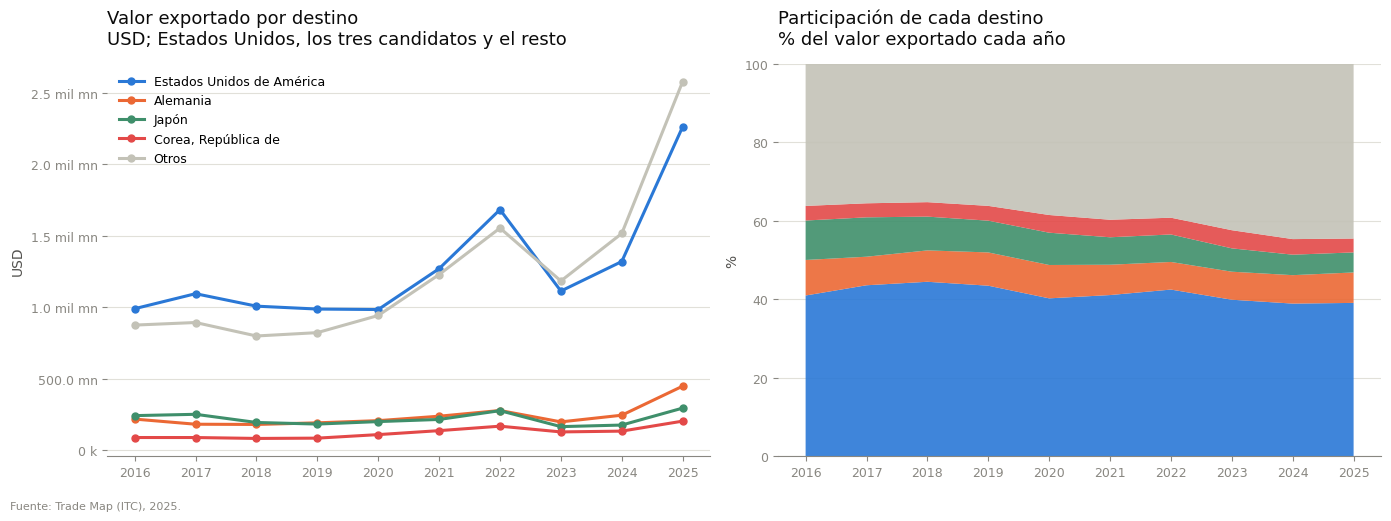

Figura guardada en salidas/g3_participacion_serie.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colores = CATEGORIAS + [GRIS_MID]
for color, columna in zip(colores, series_foco.columns):
    axes[0].plot(series_foco.index, series_foco[columna], color=color, linewidth=2.2, marker="o", markersize=5, label=columna)
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(fmt_miles))
axes[0].set_xticks(series_foco.index)
axes[0].legend(frameon=False, fontsize=9, loc="upper left")
estilo(axes[0], "Valor exportado por destino", "USD; Estados Unidos, los tres candidatos y el resto", eje_y="USD")

axes[1].stackplot(participacion_foco.index, [participacion_foco[c] for c in participacion_foco.columns], colors=colores, labels=participacion_foco.columns, alpha=0.9)
axes[1].set_ylim(0, 100)
axes[1].set_xticks(participacion_foco.index)
estilo(axes[1], "Participación de cada destino", "% del valor exportado cada año", "Trade Map (ITC), 2025.", eje_y="%")
plt.tight_layout()
guardar(fig, "g3_participacion_serie")

In [ ]:
# Crecimiento reciente por destino: CAGR 2016-2025, 2020-2025 y variacion 2024-2025
ancho = paises_serie.pivot(index="pais", columns="anio", values="valor_kusd")
top12 = ancho[2025].nlargest(12).index
crecimiento = pd.DataFrame({
    "valor_2025": ancho.loc[top12, 2025],
    "participacion_2025_pct": ancho.loc[top12, 2025] / ancho[2025].sum() * 100,
    "cagr_2016_2025_pct": [cagr(ancho.loc[p, 2016], ancho.loc[p, 2025], 9) for p in top12],
    "cagr_2020_2025_pct": [cagr(ancho.loc[p, 2020], ancho.loc[p, 2025], 5) for p in top12],
    "variacion_2024_2025_pct": (ancho.loc[top12, 2025] / ancho.loc[top12, 2024] - 1) * 100,
}).reset_index()
exportar(crecimiento, "g3_crecimiento_destinos")
crecimiento

,pais,valor_2025,participacion_2025_pct,cagr_2016_2025_pct,cagr_2020_2025_pct,variacion_2024_2025_pct
0,Estados Unidos de América,2261696,39.0741,9.6109,18.1008,71.3493
1,Bélgica,469294,8.1077,13.2371,19.7818,60.3026
2,Canadá,458247,7.9169,10.8240,20.4372,77.4047
3,Alemania,448944,7.7562,8.3120,16.6512,82.6394
4,Japón,295602,5.1070,2.2025,7.9891,66.9606
5,"Corea, República de",204505,3.5331,9.5571,13.1396,51.8541
6,China,161685,2.7933,45.7186,46.4789,12.0455
7,Países Bajos,139869,2.4164,19.9600,42.8751,120.1829
8,España,138466,2.3922,9.5002,17.5779,89.9839
9,Australia,113984,1.9692,15.7248,20.1149,73.7190


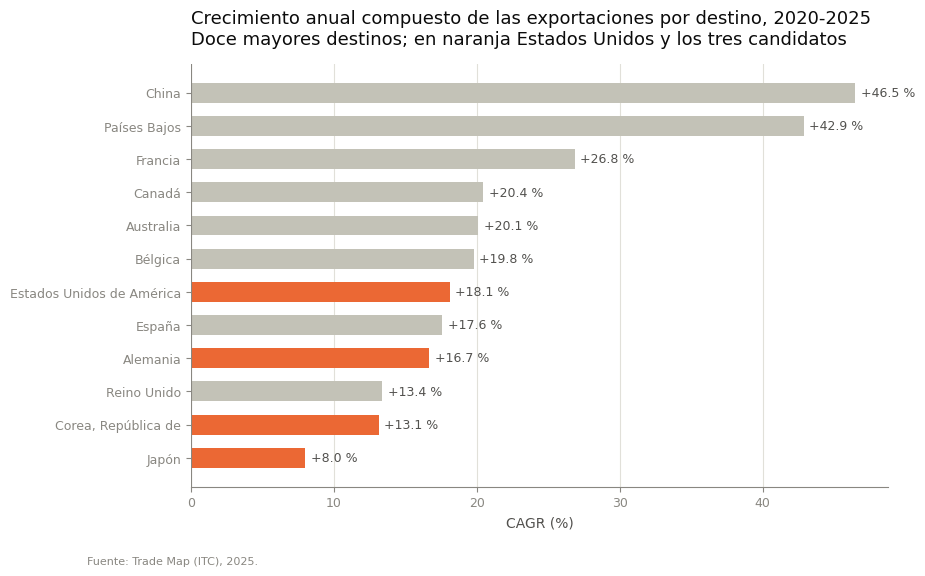

Figura guardada en salidas/g3_crecimiento_destinos.png


In [ ]:
fig, ax = plt.subplots(figsize=(9, 5.5))
orden = crecimiento.sort_values("cagr_2020_2025_pct")
colores = [NARANJA if p in FOCO else GRIS_MID for p in orden["pais"]]
ax.barh(orden["pais"], orden["cagr_2020_2025_pct"], color=colores, height=0.6)
for y, v in enumerate(orden["cagr_2020_2025_pct"]):
    ax.annotate(f"{v:+.1f} %", (v, y), textcoords="offset points", xytext=(4, 0), va="center", fontsize=9, color=GRIS_TEXT)
ax.axvline(0, color=GRIS_EJE, linewidth=0.8)
estilo(ax, "Crecimiento anual compuesto de las exportaciones por destino, 2020-2025", "Doce mayores destinos; en naranja Estados Unidos y los tres candidatos",
       "Trade Map (ITC), 2025.", eje_x="CAGR (%)", rejilla="x")
guardar(fig, "g3_crecimiento_destinos")

**Análisis del equipo:** Los tres candidatos (Alemania, Japón, Corea del Sur) muestran un crecimiento en sus exportaciones colombianas de café verde, aunque a diferentes ritmos. Comparando los CAGR de 2020-2025, Alemania (+16.7%) y Corea del Sur (+13.1%) crecen a tasas similares o ligeramente inferiores a Estados Unidos (+18.1%). Japón, sin embargo, muestra un crecimiento menor (+8.0%). Es importante notar que, si bien Estados Unidos ha crecido significativamente, los candidatos también presentan tendencias positivas que podrían ser aprovechadas para la diversificación, aunque ninguno de ellos supera consistentemente el ritmo de crecimiento de Estados Unidos en este período. Esto sugiere que la diversificación no depende de que Estados Unidos se debilite, sino de aprovechar el momento reciente de Alemania y Corea del Sur: el equipo decide monitorear el CAGR 2020-2025 (más que el de 10 años) como la señal más útil para priorizar entre los tres candidatos.

***
# 3. Concentración: CR4 y HHI de destinos

In [ ]:
concentracion = (paises_serie.groupby("anio")["valor_kusd"]
                 .agg(HHI=hhi, CR4=lambda v: cr_n(v, 4), CR1=lambda v: cr_n(v, 1), destinos_activos=lambda v: int((v > 0).sum()))
                 .reset_index())
concentracion["numero_equivalente"] = numeros_equivalentes(concentracion["HHI"])
exportar(concentracion, "g3_concentracion")
concentracion

,anio,HHI,CR4,CR1,destinos_activos,numero_equivalente
0,2016,0.2010,67.5761,40.9592,67,4.9744
1,2017,0.2187,68.4216,43.5660,66,4.5721
2,2018,0.2253,68.9961,44.4557,70,4.4390
3,2019,0.2160,67.7104,43.4571,74,4.6287
4,2020,0.1928,64.7369,40.2353,75,5.1865
5,2021,0.1977,64.8309,41.0737,80,5.0582
6,2022,0.2072,64.8827,42.4703,69,4.8254
7,2023,0.1854,61.3831,39.8853,77,5.3926
8,2024,0.1787,62.3799,38.8970,79,5.5959
9,2025,0.1795,62.8549,39.0741,77,5.5713


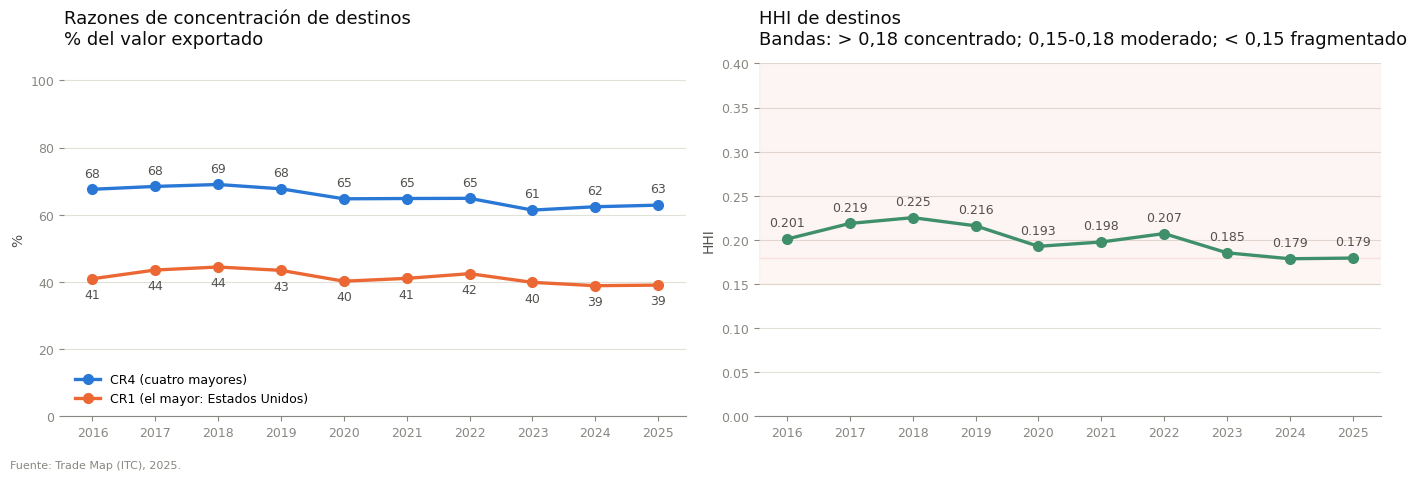

Figura guardada en salidas/g3_concentracion.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.6))
axes[0].plot(concentracion["anio"], concentracion["CR4"], color=AZUL, linewidth=2.4, marker="o", markersize=7, label="CR4 (cuatro mayores)")
axes[0].plot(concentracion["anio"], concentracion["CR1"], color=NARANJA, linewidth=2.4, marker="o", markersize=7, label="CR1 (el mayor: Estados Unidos)")
for _, fila in concentracion.iterrows():
    axes[0].annotate(f"{fila['CR4']:.0f}", (fila["anio"], fila["CR4"]), textcoords="offset points", xytext=(0, 9), ha="center", fontsize=9, color=GRIS_TEXT)
    axes[0].annotate(f"{fila['CR1']:.0f}", (fila["anio"], fila["CR1"]), textcoords="offset points", xytext=(0, -14), ha="center", fontsize=9, color=GRIS_TEXT)
axes[0].set_ylim(0, 105)
axes[0].set_xticks(concentracion["anio"])
axes[0].legend(frameon=False, fontsize=9, loc="lower left")
estilo(axes[0], "Razones de concentración de destinos", "% del valor exportado", eje_y="%")

axes[1].plot(concentracion["anio"], concentracion["HHI"], color=VERDE, linewidth=2.4, marker="o", markersize=7)
for _, fila in concentracion.iterrows():
    axes[1].annotate(f"{fila['HHI']:.3f}", (fila["anio"], fila["HHI"]), textcoords="offset points", xytext=(0, 9), ha="center", fontsize=9, color=GRIS_TEXT)
axes[1].axhspan(0.18, 1, color=ROJO, alpha=0.06)
axes[1].axhspan(0.15, 0.18, color=NARANJA, alpha=0.06)
axes[1].set_ylim(0, max(0.4, concentracion["HHI"].max() * 1.25))
axes[1].set_xticks(concentracion["anio"])
estilo(axes[1], "HHI de destinos", "Bandas: > 0,18 concentrado; 0,15-0,18 moderado; < 0,15 fragmentado", "Trade Map (ITC), 2025.", eje_y="HHI")
plt.tight_layout()
guardar(fig, "g3_concentracion")

**Análisis del equipo:** Las razones de concentración (CR4 y CR1) y el Índice de Herfindahl-Hirschman (HHI) muestran que las exportaciones de café verde colombiano siguen concentradas en pocos destinos. El CR1 (participación de Estados Unidos) se mantiene cerca del 39-40%, y el CR4 oscila entre 61% y 69% según el año. El HHI cayó de forma sostenida entre 2018 (pico de 0.225) y 2024, llegando a su punto más bajo en ese año (0.179), por debajo del umbral de 0.18. Sin embargo, esa caída se detuvo en 2023-2025: el CR4 subió de 61.4% a 62.9% y el HHI repuntó levemente en 2025 (0.180). Esto indica que la diversificación no es una tendencia lineal garantizada hubo un avance real hasta 2024, pero el último año muestra una leve reconcentración, lo que refuerza la necesidad de una estrategia activa y no de esperar a que el mercado se diversifique solo. Por eso el equipo decide fijar una meta explícita de participación combinada para Alemania, Japón y Corea del Sur (no solo "diversificar" en abstracto), ya que dejar que ocurra sola ya demostró estancarse en 2023-2025.

***
# 4. Tamaño y crecimiento de los mercados importadores

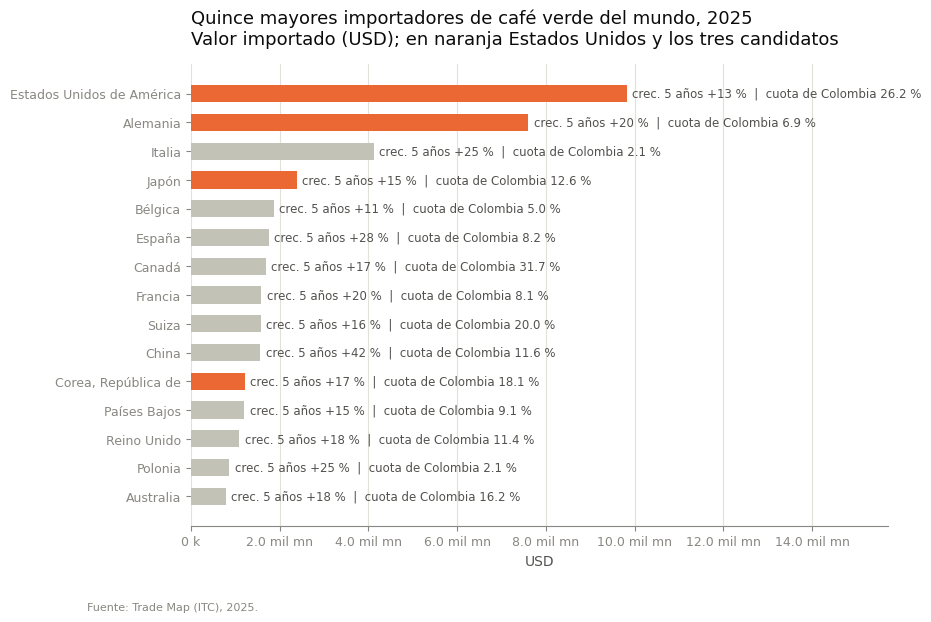

Figura guardada en salidas/g3_mercados_importadores.png


,pais,valor_kusd,cantidad,valor_unitario,participacion_mundial_pct,crec_valor_5a_pct,crec_valor_2a_pct,cuota_en_socio_pct,ranking_socio
0,Estados Unidos de América,"9,827,420.0000","1,293,837.0000","7,595.5600",19.4912,13.0000,56.0000,26.1672,1.0000
1,Alemania,"7,597,964.0000","1,115,056.0000","6,813.9800",15.0694,20.0000,47.0000,6.9171,2.0000
2,Italia,"4,124,292.0000","615,736.0000","6,698.1500",8.1799,25.0000,50.0000,2.1101,3.0000
3,Japón,"2,384,668.0000","354,953.0000","6,718.2600",4.7296,15.0000,50.0000,12.6448,4.0000
4,Bélgica,"1,867,902.0000","277,987.0000","6,719.3900",3.7047,11.0000,44.0000,4.9633,5.0000
5,España,"1,750,381.0000","292,801.0000","5,978.0600",3.4716,28.0000,50.0000,8.2422,6.0000
6,Canadá,"1,683,843.0000","223,005.0000","7,550.7000",3.3396,17.0000,63.0000,31.6512,7.0000
7,Francia,"1,586,275.0000","224,999.0000","7,050.1400",3.1461,20.0000,53.0000,8.0961,8.0000
8,Suiza,"1,570,455.0000","198,098.0000","7,927.6700",3.1148,16.0000,35.0000,19.9839,9.0000
9,China,"1,565,732.0000","228,051.0000","6,865.7100",3.1054,42.0000,87.0000,11.5760,10.0000


In [ ]:
demanda = importadores.nlargest(15, "valor_kusd")[["pais", "valor_kusd", "cantidad", "valor_unitario", "participacion_mundial_pct", "crec_valor_5a_pct", "crec_valor_2a_pct"]]
demanda = demanda.merge(destinos_2025[["pais", "cuota_en_socio_pct", "ranking_socio"]], on="pais", how="left")
exportar(demanda, "g3_mercados_importadores")
fig, ax = plt.subplots(figsize=(9, 6))
orden = demanda.sort_values("valor_kusd")
colores = [NARANJA if p in FOCO else GRIS_MID for p in orden["pais"]]
ax.barh(orden["pais"], orden["valor_kusd"], color=colores, height=0.6)
for y, (v, g, c) in enumerate(zip(orden["valor_kusd"], orden["crec_valor_5a_pct"], orden["cuota_en_socio_pct"])):
    ax.annotate(f"crec. 5 años {g:+.0f} %  |  cuota de Colombia {c:.1f} %", (v, y), textcoords="offset points", xytext=(4, 0), va="center", fontsize=8.5, color=GRIS_TEXT)
ax.xaxis.set_major_formatter(plt.FuncFormatter(fmt_miles))
ax.set_xlim(0, orden["valor_kusd"].max() * 1.6)
estilo(ax, "Quince mayores importadores de café verde del mundo, 2025", "Valor importado (USD); en naranja Estados Unidos y los tres candidatos",
       "Trade Map (ITC), 2025.", eje_x="USD", rejilla="x")
guardar(fig, "g3_mercados_importadores")
demanda

**Análisis del equipo:** En cuanto al tamaño y crecimiento de los mercados importadores, Alemania destaca como el segundo mayor importador mundial de café verde, solo por detrás de Estados Unidos, y ha mostrado un fuerte crecimiento del 20% en los últimos 5 años. Japón y Corea del Sur son mercados más pequeños en volumen de importación, pero también presentan crecimientos saludables (15% y 17% respectivamente). La cuota de Colombia en estos mercados varía: es notablemente alta en Canadá (31.7%) y Australia (16.2%), pero más modesta en Alemania (6.9%), Japón (12.6%) y Corea del Sur (18.1%). Esto sugiere que hay espacio para aumentar la participación en los mercados candidatos, especialmente en Alemania, dado su gran tamaño y crecimiento.

***
# 5. Proveedores de cada mercado candidato

In [ ]:
cuadros = {}
for nombre, tabla in proveedores.items():
    total, paises = separar_mundo(tabla)
    top = paises.nlargest(8, "valor_kusd")[["pais", "valor_kusd", "participacion_pct", "crec_valor_5a_pct", "valor_unitario"]]
    if "Colombia" not in top["pais"].values:
        top = pd.concat([top, paises[paises["pais"] == "Colombia"][top.columns]])
    top.insert(0, "mercado", nombre)
    cuadros[nombre] = top
tabla_proveedores = pd.concat(cuadros.values(), ignore_index=True)
exportar(tabla_proveedores, "g3_proveedores")
tabla_proveedores

,mercado,pais,valor_kusd,participacion_pct,crec_valor_5a_pct,valor_unitario
0,Alemania,Brasil,"2,807,436.0000",36.9498,20.0000,"7,328.9900"
1,Alemania,Viet Nam,"1,345,508.0000",17.7088,32.0000,"5,710.6000"
2,Alemania,Honduras,"552,813.0000",7.2758,8.0000,"8,302.7400"
3,Alemania,Colombia,"525,559.0000",6.9171,16.0000,"8,081.9200"
4,Alemania,Etiopía,"443,644.0000",5.8390,16.0000,"7,290.9000"
5,Alemania,Perú,"328,697.0000",4.3261,13.0000,"7,914.1200"
6,Alemania,Uganda,"328,342.0000",4.3214,30.0000,"5,421.5800"
7,Alemania,Indonesia,"282,424.0000",3.7171,48.0000,"4,939.3000"
8,Japón,Brasil,"953,397.0000",39.9803,21.0000,"6,544.1900"
9,Japón,Viet Nam,"479,676.0000",20.1150,28.0000,"5,441.5900"


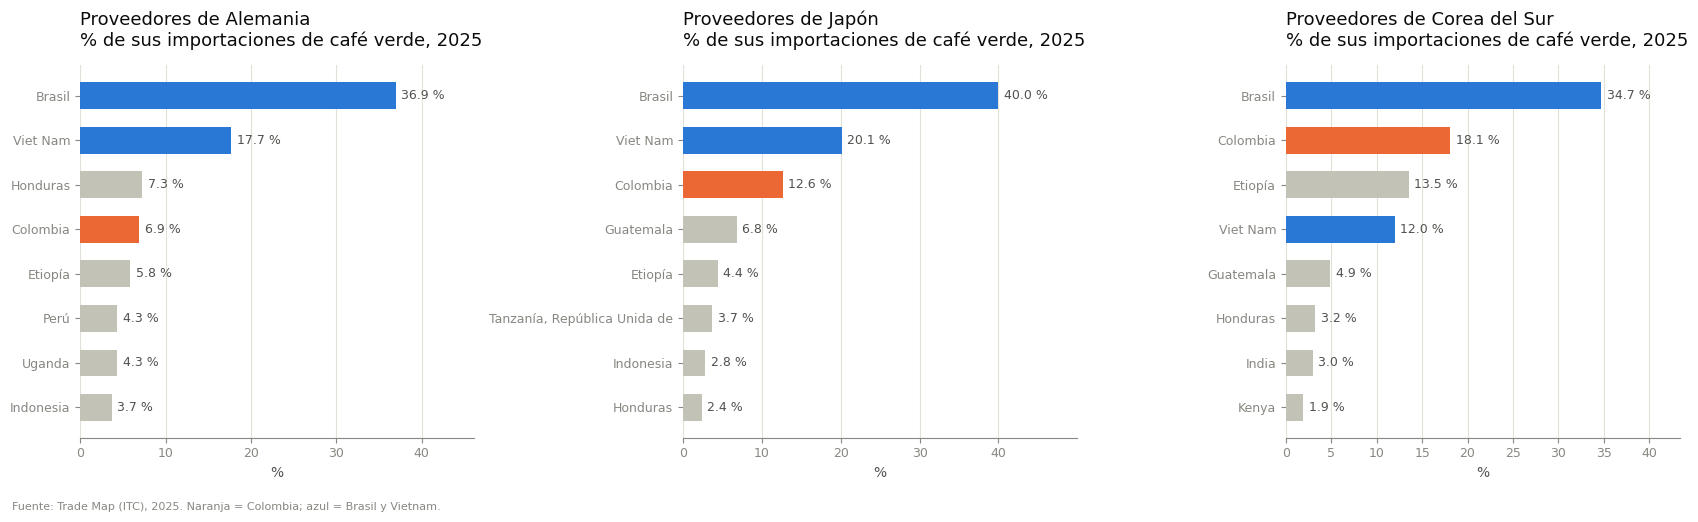

Figura guardada en salidas/g3_proveedores.png


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
for ax, (nombre, top) in zip(axes, cuadros.items()):
    orden = top.sort_values("participacion_pct")
    colores = [NARANJA if p == "Colombia" else (AZUL if p in ("Brasil", "Viet Nam") else GRIS_MID) for p in orden["pais"]]
    ax.barh(orden["pais"], orden["participacion_pct"], color=colores, height=0.6)
    for y, v in enumerate(orden["participacion_pct"]):
        ax.annotate(f"{v:.1f} %", (v, y), textcoords="offset points", xytext=(4, 0), va="center", fontsize=9, color=GRIS_TEXT)
    ax.set_xlim(0, orden["participacion_pct"].max() * 1.25)
    estilo(ax, f"Proveedores de {nombre}", "% de sus importaciones de café verde, 2025", eje_x="%", rejilla="x")
axes[2].figure.text(0.01, -0.03, "Fuente: Trade Map (ITC), 2025. Naranja = Colombia; azul = Brasil y Vietnam.", fontsize=8, color=GRIS_EJE)
plt.tight_layout()
guardar(fig, "g3_proveedores")

**Análisis del equipo:** Colombia ocupa una posición importante como proveedor en los mercados candidatos, pero no es el líder en ninguno de ellos. En Alemania, Colombia es el cuarto proveedor con un 6.9% de participación, muy por debajo de Brasil (36.9%) y Viet Nam (17.7%). En Japón, Colombia es el tercer proveedor con 12.6% de participación, superado por Brasil (39.9%) y Viet Nam (20.1%). En Corea del Sur, Colombia es el segundo proveedor con 18.1% de participación, todavía detrás de Brasil (34.7%). Esto indica que, si bien Colombia tiene una presencia establecida, enfrenta una competencia significativa, especialmente de Brasil y Viet Nam, que dominan las importaciones de estos mercados. La estrategia de diversificación deberá considerar cómo competir de manera más efectiva con estos líderes en términos de volumen o diferenciación de producto/precio.

***
# 6. Matriz comparativa de los tres destinos

Los tres bloques de la ficha (participación y crecimiento; acceso y tamaño; competencia y diferenciación). Las columnas de **arancel y condiciones de acceso** son editables porque salen de Legiscomex, no de Trade Map.

In [ ]:
# ====================== EDITABLE: arancel y acceso, desde Legiscomex ======================
ACCESO = pd.DataFrame({
    "arancel_nmf_cafe_verde_pct": [0.0, 0.0, 2.0],
    "arancel_colombia_pct":       [0.0, 0.0, 0.0],
    "condiciones_de_acceso": [
        "Acuerdo Comercial Colombia-UE: 0% para café verde. Desde 2026 aplica el Reglamento EUDR (deforestación): exige trazabilidad geolocalizada del lote y declaración de diligencia debida.",
        "Café verde entra libre de arancel a Japón para todos los orígenes (no requiere acuerdo). Exige certificado fitosanitario y cumple el sistema de lista positiva de residuos de plaguicidas.",
        "TLC Colombia-Corea (vigente desde 2016): acceso inmediato libre de arancel al café verde, frente al 2% NMF que sí pagan orígenes sin acuerdo. Requiere certificado de origen del TLC y certificado fitosanitario.",
    ],
}, index=list(CANDIDATOS.keys()))
# ===========================================================================================

filas = []
for nombre, etiqueta in CANDIDATOS.items():
    d = destinos_2025.set_index("pais").loc[etiqueta]
    m = importadores.set_index("pais").loc[etiqueta]
    lider = separar_mundo(proveedores[nombre])[1].nlargest(1, "valor_kusd").iloc[0]
    filas.append({
        "mercado": nombre,
        # 6.1 participacion y crecimiento
        "exportaciones_colombia_2025_kusd": d["valor_kusd"],
        "participacion_en_exp_colombia_pct": d["participacion_pct"],
        "cagr_2016_2025_pct": cagr(ancho.loc[etiqueta, 2016], ancho.loc[etiqueta, 2025], 9),
        "variacion_2024_2025_pct": (ancho.loc[etiqueta, 2025] / ancho.loc[etiqueta, 2024] - 1) * 100,
        # 6.2 tamano del mercado y acceso
        "importaciones_totales_2025_kusd": m["valor_kusd"],
        "crec_importaciones_5a_pct": m["crec_valor_5a_pct"],
        "precio_importacion_usd_t": m["valor_unitario"],
        # 6.3 competencia
        "cuota_colombia_pct": d["cuota_en_socio_pct"],
        "puesto_colombia": d["ranking_socio"],
        "proveedor_lider": lider["pais"],
        "cuota_lider_pct": lider["participacion_pct"],
    })
matriz = pd.DataFrame(filas).set_index("mercado").join(ACCESO)
exportar(matriz.reset_index(), "g3_matriz_comparativa")
matriz.T

mercado,Alemania,Japón,Corea del Sur
exportaciones_colombia_2025_kusd,"448,944.0000","295,602.0000","204,505.0000"
participacion_en_exp_colombia_pct,7.7562,5.1070,3.5331
cagr_2016_2025_pct,8.3120,2.2025,9.5571
variacion_2024_2025_pct,82.6394,66.9606,51.8541
importaciones_totales_2025_kusd,"7,597,964.0000","2,384,668.0000","1,212,437.0000"
crec_importaciones_5a_pct,20.0000,15.0000,17.0000
precio_importacion_usd_t,"6,813.9800","6,718.2600","7,241.8500"
cuota_colombia_pct,6.9171,12.6448,18.0701
puesto_colombia,2.0000,4.0000,11.0000
proveedor_lider,Brasil,Brasil,Brasil


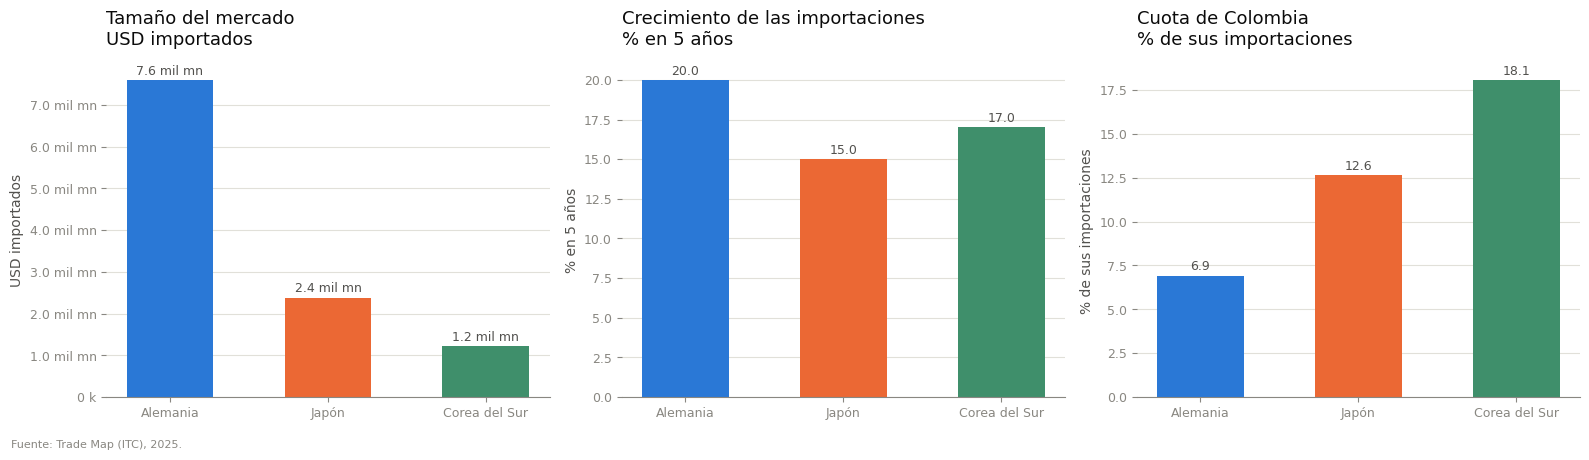

Figura guardada en salidas/g3_matriz_comparativa.png


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.4))
indicadores = [("importaciones_totales_2025_kusd", "Tamaño del mercado", "USD importados"),
               ("crec_importaciones_5a_pct", "Crecimiento de las importaciones", "% en 5 años"),
               ("cuota_colombia_pct", "Cuota de Colombia", "% de sus importaciones")]
for ax, (col, titulo, unidad) in zip(axes, indicadores):
    valores = matriz[col]
    ax.bar(valores.index, valores, color=CATEGORIAS[:3], width=0.55)
    for x, v in enumerate(valores):
        ax.annotate(fmt_miles(v) if "kusd" in col else f"{v:.1f}", (x, v), textcoords="offset points", xytext=(0, 4), ha="center", fontsize=9, color=GRIS_TEXT)
    if "kusd" in col:
        ax.yaxis.set_major_formatter(plt.FuncFormatter(fmt_miles))
    estilo(ax, titulo, unidad, eje_y=unidad)
axes[2].figure.text(0.01, -0.03, "Fuente: Trade Map (ITC), 2025.", fontsize=8, color=GRIS_EJE)
plt.tight_layout()
guardar(fig, "g3_matriz_comparativa")

**Análisis del equipo:** Analizando la matriz comparativa, Alemania es el mercado más grande de los tres candidatos en importaciones totales, y también el que más creció en importaciones en 5 años (20%). Colombia tiene su menor cuota de mercado justamente en Alemania (6.9%), frente a Japón (12.6%) y Corea del Sur (18.1%). En precio de importación, Corea del Sur tiene el valor unitario más alto (USD 7,242/t vs. USD 6,814 en Alemania y USD 6,718 en Japón). El café verde colombiano entra libre de arancel en los tres mercados, pero no todos por la misma razón: en Japón y Alemania el arancel ya es 0% para cualquier origen, mientras que en Corea del Sur ese 0% depende directamente del TLC Colombia-Corea (frente al 2% que pagaría un país sin acuerdo). La condición de acceso más exigente es la de Alemania, por el Reglamento EUDR que exige trazabilidad geolocalizada desde 2026. La competencia en los tres mercados la lidera Brasil. Esto sugiere que Alemania ofrece el mayor potencial de volumen pero con la menor cuota actual de Colombia y requisitos más complejos, mientras que Corea del Sur, aunque más pequeño, ofrece mejor precio y mayor cuota de Colombia, con acceso preferencial claramente respaldado por un acuerdo comercial.

***
# 7. Escenarios de diversificación

La ficha propone tomar la participación actual de cada mercado, aplicarle una tasa de crecimiento durante dos años y **mantener fijas las exportaciones totales**: lo que ganan los tres candidatos lo pierde Estados Unidos. Los tres escenarios y sus tasas son **editables**.

In [ ]:
# ====================== EDITABLE: escenarios (crecimiento anual, %) ======================
ESCENARIOS = {
    "Actual":              {"Alemania": 0,    "Japón": 0,   "Corea del Sur": 0},
    "Tendencia larga (CAGR 2016-2025)":   {"Alemania": 8,  "Japón": 2,   "Corea del Sur": 10},
    "Tendencia reciente (CAGR 2020-2025)": {"Alemania": 17, "Japón": 8,   "Corea del Sur": 13},
}
ANIOS_PROYECCION = 2
# ==========================================================================================

def proyectar(participaciones, crecimientos, anios, absorbe=EEUU):
    """Aplica crecimiento a los mercados indicados manteniendo el total en 100 %; el mercado `absorbe` recibe el residuo."""
    nuevas = participaciones.copy()
    for mercado, tasa in crecimientos.items():
        etiqueta = CANDIDATOS[mercado]
        nuevas[etiqueta] = participaciones[etiqueta] * (1 + tasa / 100) ** anios
    ganancia = nuevas.sum() - participaciones.sum()
    nuevas[absorbe] = participaciones[absorbe] - ganancia
    return nuevas

participacion_2025 = destinos_2025.set_index("pais")["participacion_pct"]
resultado = pd.DataFrame({nombre: proyectar(participacion_2025, tasas, ANIOS_PROYECCION) for nombre, tasas in ESCENARIOS.items()})
resultado = resultado.loc[FOCO]
resultado.loc["Otros"] = 100 - resultado.sum()
exportar(resultado.reset_index(), "g3_escenarios")
resultado.round(2)

,Actual,Tendencia larga (CAGR 2016-2025),Tendencia reciente (CAGR 2020-2025)
pais,,,
Estados Unidos de América,39.0700,36.8400,34.3800
Alemania,7.7600,9.0500,10.6200
Japón,5.1100,5.3100,5.9600
"Corea, República de",3.5300,4.2800,4.5100
Otros,44.5300,44.5300,44.5300


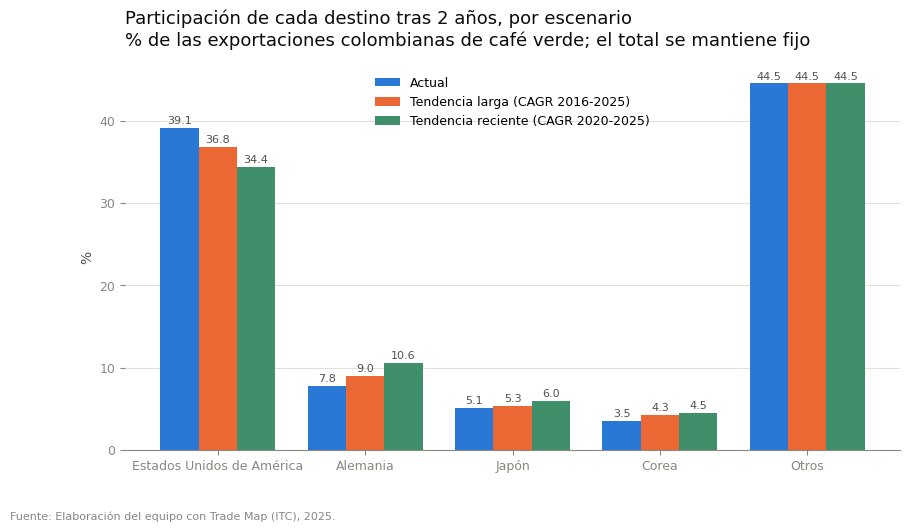

Figura guardada en salidas/g3_escenarios.png


In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
mercados = resultado.index.tolist()
x = np.arange(len(mercados))
ancho_barra = 0.26
for i, (escenario, color) in enumerate(zip(resultado.columns, CATEGORIAS)):
    barras = ax.bar(x + (i - 1) * ancho_barra, resultado[escenario], width=ancho_barra, color=color, label=escenario)
    for b in barras:
        ax.annotate(f"{b.get_height():.1f}", (b.get_x() + b.get_width() / 2, b.get_height()), textcoords="offset points", xytext=(0, 3), ha="center", fontsize=8, color=GRIS_TEXT)
ax.set_xticks(x)
ax.set_xticklabels([m.replace(", República de", "") for m in mercados])
ax.legend(frameon=False, fontsize=9)
estilo(ax, f"Participación de cada destino tras {ANIOS_PROYECCION} años, por escenario", "% de las exportaciones colombianas de café verde; el total se mantiene fijo",
       "Elaboración del equipo con Trade Map (ITC), 2025.", eje_y="%")
guardar(fig, "g3_escenarios")

**Análisis del equipo:** Los escenarios de diversificación muestran que, si los mercados candidatos crecen según las tendencias, la participación de Estados Unidos en las exportaciones colombianas disminuiría, redistribuyendo parte de esa cuota hacia Alemania, Japón y Corea del Sur. El supuesto más frágil probablemente sea mantener las exportaciones totales fijas, ya que en la realidad, el crecimiento en nuevos mercados podría complementar y no necesariamente sustituir las exportaciones a Estados Unidos, a menos que haya una capacidad de producción limitada. Además, las tasas de crecimiento proyectadas son estimaciones y pueden variar. En cuanto a una participación aceptable de Estados Unidos, esto depende de la estrategia de riesgo del equipo. Sin embargo, reducirla del actual 39.1% a, por ejemplo, el 34.4% del escenario de 'Tendencia reciente' es un paso significativo hacia una menor dependencia, mejorando la resiliencia ante posibles fluctuaciones en el mercado estadounidense.

***
# Entrega

1. Revisa que todas las celdas **Análisis del equipo** tengan texto.  
2. `Archivo → Descargar → Descargar .ipynb`.  
3. Sube el archivo al aula virtual. Las figuras y tablas de `salidas/` pueden ir al informe escrito.

# Referencias

Baena-Rojas, J. J., & Cano, J. A. (2026). International market selection for exports of goods: A data analysis technique for organizational decision-making. *Global Business Review*. https://doi.org/10.1177/09721509261464305

International Trade Centre. (2025). *Trade Map: Trade statistics for international business development*. https://www.trademap.org

Durán Lima, J. E. (s.f.). *Indicadores de comercio exterior y política comercial: Generalidades metodológicas e indicadores básicos*. CEPAL.

McKinney, W. (2010). Data structures for statistical computing in Python. *Proceedings of the 9th Python in Science Conference*, 56–61. https://doi.org/10.25080/Majora-92bf1922-00a

Hunter, J. D. (2007). Matplotlib: A 2D graphics environment. *Computing in Science & Engineering, 9*(3), 90–95. https://doi.org/10.1109/MCSE.2007.55

CIERRE FINAL DEL EQUIPO

Como equipo recomendamos priorizar Alemania como principal mercado de diversificación, y Corea del Sur como segunda prioridad, dejando a Japón en un tercer lugar por su crecimiento más lento (CAGR 2016-2025 de solo 2.2%, muy por debajo de los otros dos).

La evidencia detrás de Alemania: es el mercado más grande de los tres (USD 7.6 mil millones en importaciones, 2º importador mundial), el que más creció en importaciones en 5 años (20%) y el que más aceleró en el último año (variación 2024-2025 de 82.6%, por encima incluso de Estados Unidos). El arancel es 0% y no depende de negociación. El riesgo real no es comercial sino regulatorio: el Reglamento EUDR de la UE exige trazabilidad geolocalizada desde 2026, así que la condición para escalar en este mercado es invertir primero en esa trazabilidad antes que en volumen.

La evidencia detrás de Corea del Sur: aunque es el mercado más pequeño de los tres (USD 1.2 mil millones), Colombia ya es su segundo proveedor con 18.1% de cuota muy por encima de su posición en Alemania (4º, 6.9%) o Japón (3º, 12.6%), tiene el precio unitario más alto de los tres destinos (USD 7,242/t) y el acceso libre de arancel está garantizado por un TLC vigente, sin condiciones adicionales de acceso como el EUDR.

En conjunto, esta estrategia reduciría la dependencia de Estados Unidos de 39.1% a cerca de 34.4% en dos años (escenario de tendencia reciente), sin sacrificar el mercado estadounidense, que sigue creciendo por sí solo.




::: {.pie-ean}
**Equipo 3 · Café verde · HS 090111** · Proyecto final de Inteligencia en Negocios Globales, Universidad EAN, septiembre de 2026. Docente: Alejandra Otero. Sitio construido con [Quarto](https://quarto.org) a partir del cuaderno de análisis del equipo.
:::
